<a href="https://colab.research.google.com/github/phamhoquephuong/Ph-m-H-Qu-Ph-ng_31251021113_BTVN-1/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Section

Bài 2.11

In [2]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 14.8 MB/s eta 0:00:00


Giá cước: 80.55555555555556
Điểm thưởng: 81.94444444444441


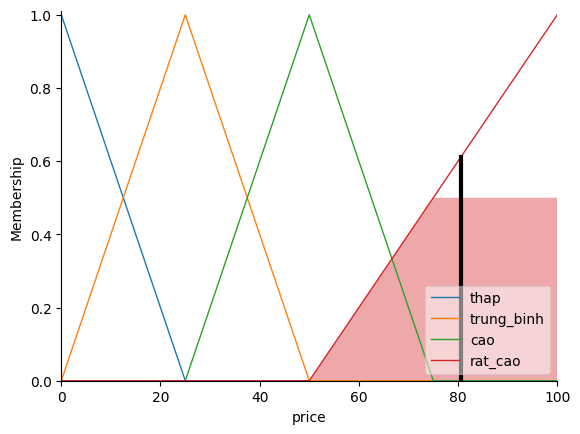

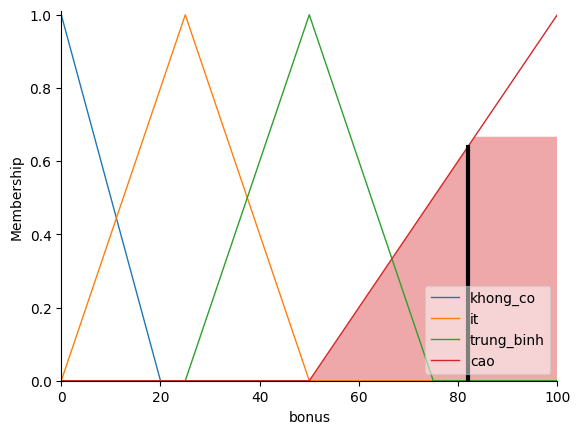

In [11]:
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

distance = ctrl.Antecedent(np.arange(0, 51, 1), 'distance')
traffic = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic')
demand = ctrl.Antecedent(np.arange(0, 101, 1), 'demand')
weather = ctrl.Antecedent(np.arange(0, 11, 1), 'weather')
rating = ctrl.Antecedent(np.arange(1, 6, 0.5), 'rating')
punctuality = ctrl.Antecedent(np.arange(0, 101, 1), 'punctuality')

price = ctrl.Consequent(np.arange(0, 101, 1), 'price')
bonus = ctrl.Consequent(np.arange(0, 101, 1), 'bonus')

distance['ngan'] = fuzzy.trimf(distance.universe, [0, 0, 3])
distance['trung_binh'] = fuzzy.trimf(distance.universe, [2, 5, 8])
distance['xa'] = fuzzy.trimf(distance.universe, [6, 13, 20])
distance['rat_xa'] = fuzzy.trimf(distance.universe, [15, 32.5, 50])

for var in [traffic, demand]:
    var['thap'] = fuzzy.trimf(var.universe, [0, 0, 30])
    var['trung_binh'] = fuzzy.trimf(var.universe, [20, 45, 70])
    var['cao'] = fuzzy.trimf(var.universe, [60, 100, 100])

weather['tot'] = fuzzy.trimf(weather.universe, [0, 0, 5])
weather['trung_binh'] = fuzzy.trimf(weather.universe, [0, 5, 10])
weather['xau'] = fuzzy.trimf(weather.universe, [5, 10, 10])

rating['kem'] = fuzzy.trimf(rating.universe, [1, 1, 2.5])
rating['trung_binh'] = fuzzy.trimf(rating.universe, [2, 3, 4])
rating['tot'] = fuzzy.trimf(rating.universe, [3.5, 5, 5])

punctuality['tre'] = fuzzy.trimf(punctuality.universe, [0, 0, 50])
punctuality['dung_gio'] = fuzzy.trimf(punctuality.universe, [40, 60, 80])
punctuality['som'] = fuzzy.trimf(punctuality.universe, [70, 100, 100])

price['thap'] = fuzzy.trimf(price.universe, [0, 0, 25])
price['trung_binh'] = fuzzy.trimf(price.universe, [0, 25, 50])
price['cao'] = fuzzy.trimf(price.universe, [25, 50, 75])
price['rat_cao'] = fuzzy.trimf(price.universe, [50, 100, 100])

bonus['khong_co'] = fuzzy.trimf(bonus.universe, [0, 0, 20])
bonus['it'] = fuzzy.trimf(bonus.universe, [0, 25, 50])
bonus['trung_binh'] = fuzzy.trimf(bonus.universe, [25, 50, 75])
bonus['cao'] = fuzzy.trimf(bonus.universe, [50, 100, 100])

rules = [
    ctrl.Rule(distance['ngan'] & traffic['thap'] & demand['thap'], price['thap']),
    ctrl.Rule(distance['ngan'] & traffic['trung_binh'] & demand['cao'], price['trung_binh']),
    ctrl.Rule(distance['trung_binh'] & traffic['cao'] & demand['cao'], price['cao']),
    ctrl.Rule(distance['xa'] & traffic['trung_binh'] & weather['tot'], price['trung_binh']),
    ctrl.Rule(distance['xa'] & traffic['cao'] & weather['xau'], price['rat_cao']),
    ctrl.Rule(distance['rat_xa'] & traffic['cao'] & demand['cao'], price['rat_cao']),
    ctrl.Rule(distance['trung_binh'] & traffic['thap'] & demand['thap'], price['trung_binh']),
    ctrl.Rule(distance['ngan'] & traffic['cao'] & weather['xau'], price['cao']),
    ctrl.Rule(distance['rat_xa'] & weather['xau'], price['rat_cao']),
    ctrl.Rule(distance['trung_binh'] & traffic['trung_binh'] & weather['trung_binh'], price['trung_binh']),
    ctrl.Rule(rating['tot'] & punctuality['som'], bonus['cao']),
    ctrl.Rule(rating['trung_binh'] & punctuality['dung_gio'], bonus['trung_binh']),
    ctrl.Rule(rating['kem'] & punctuality['tre'], bonus['khong_co']),
    ctrl.Rule(distance['xa'] & traffic['cao'] & punctuality['dung_gio'], bonus['cao']),
    ctrl.Rule(distance['trung_binh'] & traffic['trung_binh'] & rating['tot'], bonus['trung_binh']),
    ctrl.Rule(rating['kem'] & punctuality['tre'], bonus['khong_co']),
    ctrl.Rule(distance['rat_xa'] & weather['xau'] & rating['tot'], bonus['cao']),
    ctrl.Rule(distance['ngan'] & rating['trung_binh'] & punctuality['dung_gio'], bonus['it']),
    ctrl.Rule(distance['xa'] & traffic['cao'] & punctuality['tre'], bonus['it']),
    ctrl.Rule(distance['trung_binh'] & weather['trung_binh'] & rating['tot'], bonus['trung_binh'])
]

grab_ctrl = ctrl.ControlSystem(rules)
grab_sim = ctrl.ControlSystemSimulation(grab_ctrl)

grab_sim.input['distance'] = 10
grab_sim.input['traffic'] = 80
grab_sim.input['demand'] = 90
grab_sim.input['weather'] = 9
grab_sim.input['rating'] = 4.8
grab_sim.input['punctuality'] = 90

grab_sim.compute()

print(f"Giá cước: {grab_sim.output['price']}")
print(f"Điểm thưởng: {grab_sim.output['bonus']}")

price.view(sim=grab_sim)
bonus.view(sim=grab_sim)
plt.show()

Bài 2.12

54.999999999999986


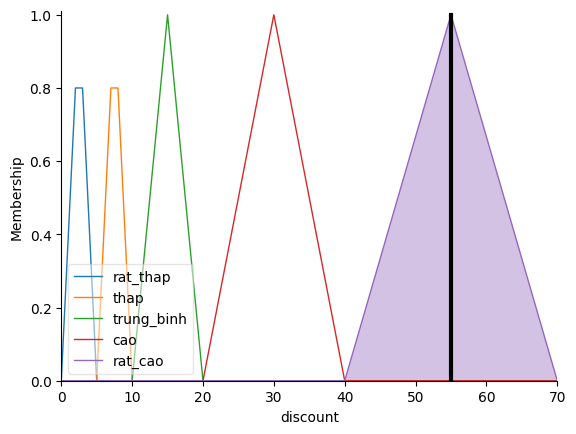

In [10]:
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

rating = ctrl.Antecedent(np.arange(0, 6, 1), 'rating')
sales = ctrl.Antecedent(np.arange(0, 11, 1), 'sales')
margin = ctrl.Antecedent(np.arange(0, 11, 1), 'margin')
seasonal = ctrl.Antecedent(np.arange(0, 11, 1), 'seasonal')
comp_discount = ctrl.Antecedent(np.arange(0, 11, 1), 'comp_discount')

discount = ctrl.Consequent(np.arange(0, 71, 1), 'discount')

rating['thap'] = fuzzy.trimf(rating.universe, [0, 0, 4])
rating['trung_binh'] = fuzzy.trimf(rating.universe, [4, 4.25, 4.5])
rating['cao'] = fuzzy.trimf(rating.universe, [4.5, 5, 5])

for var in [sales, margin, seasonal, comp_discount]:
    var['thap'] = fuzzy.trimf(var.universe, [0, 0, 5])
    var['trung_binh'] = fuzzy.trimf(var.universe, [0, 5, 10])
    var['cao'] = fuzzy.trimf(var.universe, [5, 10, 10])

seasonal['khong_co'] = fuzzy.trimf(seasonal.universe, [0, 0, 2])

discount['rat_thap'] = fuzzy.trimf(discount.universe, [0, 2.5, 5])
discount['thap'] = fuzzy.trimf(discount.universe, [5, 7.5, 10])
discount['trung_binh'] = fuzzy.trimf(discount.universe, [10, 15, 20])
discount['cao'] = fuzzy.trimf(discount.universe, [20, 30, 40])
discount['rat_cao'] = fuzzy.trimf(discount.universe, [40, 55, 70])

rules = [
    ctrl.Rule(rating['cao'] & sales['cao'] & margin['cao'], discount['rat_thap']),
    ctrl.Rule(rating['thap'] & sales['thap'] & margin['cao'], discount['cao']),
    ctrl.Rule(seasonal['cao'] & comp_discount['cao'], discount['rat_cao']),
    ctrl.Rule(rating['trung_binh'] & sales['trung_binh'] & margin['trung_binh'], discount['trung_binh']),
    ctrl.Rule(comp_discount['thap'] & margin['thap'] & sales['cao'], discount['rat_thap']),
    ctrl.Rule(rating['thap'] & seasonal['khong_co'], discount['trung_binh']),
    ctrl.Rule(sales['thap'] & margin['thap'], discount['rat_cao'])
]

shopee_strategy = ctrl.ControlSystem(rules)
calculator = ctrl.ControlSystemSimulation(shopee_strategy)

calculator.input['rating'] = 4.3
calculator.input['sales'] = 5
calculator.input['margin'] = 2
calculator.input['seasonal'] = 10
calculator.input['comp_discount'] = 10

calculator.compute()

print(calculator.output['discount'])
discount.view(sim=calculator)
plt.show()

Bài 2.13

Ket qua ket hop: 8.6
Ket qua uu tien: 50.0%


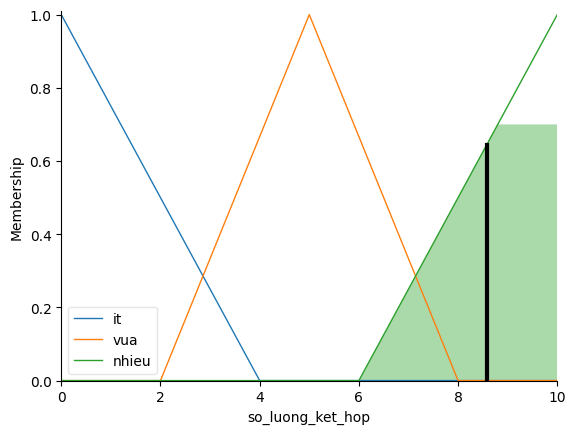

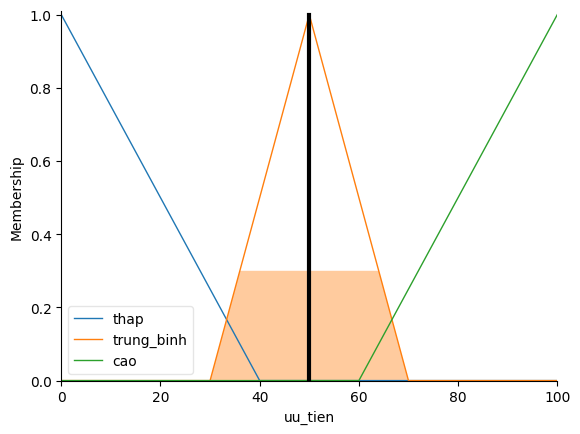

In [22]:
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

demand = ctrl.Antecedent(np.arange(0, 11, 1), 'demand')
competition = ctrl.Antecedent(np.arange(0, 11, 1), 'competition')
reputation = ctrl.Antecedent(np.arange(0, 11, 1), 'reputation')
margin = ctrl.Antecedent(np.arange(0, 11, 1), 'margin')
seasonal = ctrl.Antecedent(np.arange(0, 11, 1), 'seasonal')
discount = ctrl.Consequent(np.arange(0, 71, 1), 'discount')

for var in [demand, competition, reputation, margin, seasonal]:
    var['thap'] = fuzzy.trimf(var.universe, [0, 0, 5])
    var['trung_binh'] = fuzzy.trimf(var.universe, [0, 5, 10])
    var['cao'] = fuzzy.trimf(var.universe, [5, 10, 10])

seasonal['khong_co'] = fuzzy.trimf(seasonal.universe, [0, 0, 2])

discount['rat_thap'] = fuzzy.trimf(discount.universe, [0, 2.5, 5])
discount['thap'] = fuzzy.trimf(discount.universe, [5, 7.5, 10])
discount['trung_binh'] = fuzzy.trimf(discount.universe, [10, 15, 20])
discount['cao'] = fuzzy.trimf(discount.universe, [20, 30, 40])
discount['rat_cao'] = fuzzy.trimf(discount.universe, [40, 55, 70])

rules = [
    ctrl.Rule(demand['cao'] & competition['thap'] & margin['thap'], discount['rat_thap']),
    ctrl.Rule(demand['thap'] & competition['cao'] & margin['cao'], discount['cao']),
    ctrl.Rule(reputation['cao'] & margin['trung_binh'] & seasonal['cao'], discount['trung_binh']),
    ctrl.Rule(competition['cao'] & seasonal['cao'] & margin['cao'], discount['rat_cao']),
    ctrl.Rule(reputation['thap'] & demand['trung_binh'] & margin['thap'], discount['trung_binh']),
    ctrl.Rule(demand['cao'] & seasonal['khong_co'] & competition['thap'], discount['rat_thap']),
    ctrl.Rule(margin['cao'] & competition['trung_binh'] & seasonal['trung_binh'], discount['trung_binh'])
]

shopee_ctrl = ctrl.ControlSystem(rules)
shopee_sim = ctrl.ControlSystemSimulation(shopee_ctrl)

shopee_sim.input['demand'] = 10
shopee_sim.input['competition'] = 5
shopee_sim.input['reputation'] = 8.4
shopee_sim.input['margin'] = 9
shopee_sim.input['seasonal'] = 10

shopee_sim.compute()

print(shopee_sim.output['discount'])
discount.view(sim=shopee_sim)
plt.show()

Bài 2.14

Ket qua ket hop: 8.6
Ket qua uu tien: 50.0%


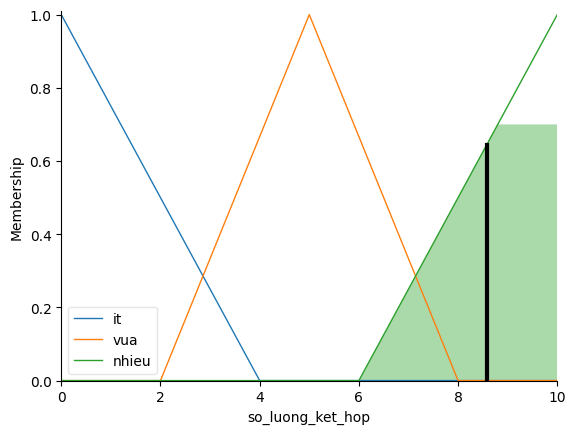

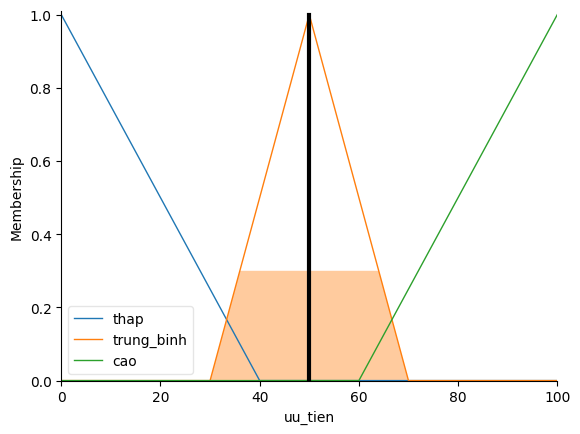

In [23]:
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

mat_do = ctrl.Antecedent(np.arange(0, 101, 1), 'mat_do')
khan_cap = ctrl.Antecedent(np.arange(0, 101, 1), 'khan_cap')
tai_trong = ctrl.Antecedent(np.arange(0, 101, 1), 'tai_trong')
giao_thong = ctrl.Antecedent(np.arange(0, 101, 1), 'giao_thong')
loi_nhuan = ctrl.Antecedent(np.arange(0, 101, 1), 'loi_nhuan')

so_luong_ket_hop = ctrl.Consequent(np.arange(0, 11, 1), 'so_luong_ket_hop')
uu_tien = ctrl.Consequent(np.arange(0, 101, 1), 'uu_tien')

names = ['thap', 'trung_binh', 'cao']
mat_do.automf(names=names)
khan_cap.automf(names=names)
tai_trong.automf(names=names)
giao_thong.automf(names=names)
loi_nhuan.automf(names=names)

so_luong_ket_hop['it'] = fuzzy.trimf(so_luong_ket_hop.universe, [0, 0, 4])
so_luong_ket_hop['vua'] = fuzzy.trimf(so_luong_ket_hop.universe, [2, 5, 8])
so_luong_ket_hop['nhieu'] = fuzzy.trimf(so_luong_ket_hop.universe, [6, 10, 10])

uu_tien['thap'] = fuzzy.trimf(uu_tien.universe, [0, 0, 40])
uu_tien['trung_binh'] = fuzzy.trimf(uu_tien.universe, [30, 50, 70])
uu_tien['cao'] = fuzzy.trimf(uu_tien.universe, [60, 100, 100])

rules = [
    ctrl.Rule(mat_do['cao'] & tai_trong['thap'] & giao_thong['thap'], so_luong_ket_hop['nhieu']),
    ctrl.Rule(mat_do['trung_binh'] & giao_thong['cao'] & khan_cap['trung_binh'], so_luong_ket_hop['vua']),
    ctrl.Rule(tai_trong['cao'] & mat_do['cao'] & loi_nhuan['trung_binh'], so_luong_ket_hop['vua']),
    ctrl.Rule(mat_do['thap'] & khan_cap['cao'] & giao_thong['trung_binh'], so_luong_ket_hop['vua']),
    ctrl.Rule(loi_nhuan['cao'] & khan_cap['cao'] & giao_thong['cao'], so_luong_ket_hop['vua']),
    ctrl.Rule(khan_cap['cao'] & loi_nhuan['cao'], uu_tien['cao']),
    ctrl.Rule(khan_cap['trung_binh'] & giao_thong['trung_binh'], uu_tien['trung_binh']),
    ctrl.Rule(khan_cap['thap'] & mat_do['cao'] & loi_nhuan['thap'], uu_tien['thap'])
]

he_thong_logistics = ctrl.ControlSystem(rules)
mo_phong = ctrl.ControlSystemSimulation(he_thong_logistics)

mo_phong.input['mat_do'] = 85
mo_phong.input['khan_cap'] = 40
mo_phong.input['tai_trong'] = 10
mo_phong.input['giao_thong'] = 15
mo_phong.input['loi_nhuan'] = 70

mo_phong.compute()

print(f"Ket qua ket hop: {mo_phong.output['so_luong_ket_hop']:.1f}")
print(f"Ket qua uu tien: {mo_phong.output['uu_tien']:.1f}%")

so_luong_ket_hop.view(sim=mo_phong)
uu_tien.view(sim=mo_phong)
plt.show()